## Mục tiêu 
Rà soát và phân tích các sự kiện bất thường (Market Shocks) trên các loại tài sản, nhằm:
* **Phát hiện Anomaly tự động:** Xây dựng thuật toán Rolling Z-score để quét các điểm đột biến về giá và khối lượng.
* **Đánh giá rủi ro đa tài sản:** Chuẩn hóa mật độ điểm bất thường (Anomaly Rate) để xếp hạng độ rủi ro khách quan giữa các nhóm tài sản.
* **Phân tích Hiệu ứng lây lan:** Quan sát phản ứng chuỗi của thị trường (Crypto, Stock, Index, Commodity) trong cùng một khung thời gian xảy ra khủng hoảng.
* **Định hướng Feature Engineering:** Rút ra các biến mới (is_anomaly) và xác định phương pháp xử lý dữ liệu (Robust Scaling, Regime Switching) cho các mô hình dự báo học máy ở giai đoạn sau.

## Import các thư viện cần thiết

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

## 1. Chuẩn bị dữ liệu 

In [32]:
file_path = max(
    Path("../data/snapshots").glob("market_snapshot_*.csv")
)
print("Latest snapshot:", file_path)
df = pd.read_csv(file_path)

def classify_asset(symbol: str) -> str:
    if "-USD" in symbol:
        return "Crypto"
    if symbol.startswith("^"):
        return "Index"
    if symbol in ["GC=F", "SI=F", "XAUUSD=X", "XAGUSD=X"]:
        return "Commodity"
    if "=X" in symbol:
        return "Forex"
    return "Stock"

numeric_columns = ["open", "high", "low", "close", "volume"]

df["datetime"] = pd.to_datetime(df["time_timestamp"], unit="s")
df = df.sort_values(["symbol", "datetime"]).reset_index(drop=True)
df[numeric_columns] = df.groupby("symbol")[numeric_columns].transform(lambda group: group.ffill().bfill())
df["asset_class"] = df["symbol"].map(classify_asset)

Latest snapshot: ..\data\snapshots\market_snapshot_20260510_150719.csv


## 2. Xây dựng hệ thống phát hiện bất thường

In [33]:
def build_features(group):
    group = group.sort_values("datetime").copy()
    group["simple_return"] = group["close"].pct_change()
    group["log_return"] = np.log(group["close"] / group["close"].shift(1))
    group["volume_change"] = group["volume"].pct_change()
    
    window = 24
    group["rolling_volatility"] = group["log_return"].rolling(window, min_periods=12).std()
    
    # Tính Z-score cho Return
    roll_mean_ret = group["log_return"].rolling(window, min_periods=12).mean()
    roll_std_ret = group["rolling_volatility"]
    group["z_score_return"] = (group["log_return"] - roll_mean_ret) / roll_std_ret.replace(0, np.nan)
    
    # Tính Z-score cho Volume
    roll_mean_vol = group["volume_change"].rolling(window, min_periods=12).mean()
    roll_std_vol = group["volume_change"].rolling(window, min_periods=12).std()
    group["z_score_volume"] = (group["volume_change"] - roll_mean_vol) / roll_std_vol.replace(0, np.nan)
    
    return group

df = df.groupby("symbol", group_keys=False).apply(build_features).reset_index(drop=True)
df[["simple_return", "log_return", "volume_change"]] = df[["simple_return", "log_return", "volume_change"]].replace([np.inf, -np.inf], np.nan)

df["anomaly_flag"] = df["z_score_return"].abs() > 3
df["volume_confirmation"] = df["z_score_volume"].abs() > 2

df["anomaly_type"] = np.select(
    [df["z_score_return"] > 3, df["z_score_return"] < -3],
    ["Spike", "Crash"],
    default="Normal"
)

anomaly_events = df.loc[
    df["anomaly_flag"],
    ["symbol", "asset_class", "datetime", "close", "log_return", "volume_change", 
     "z_score_return", "z_score_volume", "anomaly_flag", "volume_confirmation", "anomaly_type"]
].copy()

print(f"Tổng số sự kiện dị biệt (Anomalies): {len(anomaly_events)}")

Tổng số sự kiện dị biệt (Anomalies): 916


## 3. Bảng xếp hạng Rủi ro & Top Sự kiện Cực đoan

Do thời gian giao dịch của các lớp tài sản khác nhau (Crypto 24/7 vs Stock 24/5), việc so sánh số lượng Anomaly tuyệt đối sẽ gây ra thiên kiến. Chúng ta sử dụng **Anomaly Rate (%)** (Tỷ lệ điểm dị biệt trên tổng số giờ giao dịch) để chuẩn hóa và đánh giá khách quan độ rủi ro hệ thống của từng tài sản.

In [34]:
stats = df.groupby(['symbol', 'asset_class']).agg(
    total_obs=('log_return', 'count'),
    anomalies=('anomaly_flag', 'sum')
).reset_index()

stats['anomaly_rate_pct'] = (stats['anomalies'] / stats['total_obs']) * 100
leaderboard = stats.sort_values('anomaly_rate_pct', ascending=False)

print("BẢNG XẾP HẠNG MẬT ĐỘ RỦI RO (TOP 10):")
display(leaderboard.head(10).round(3))

real_crashes = anomaly_events[(anomaly_events['anomaly_type'] == 'Crash') & (anomaly_events['volume_confirmation'] == True)]
top_crashes = real_crashes.nsmallest(5, 'z_score_return')

print("\nTOP 5 CÚ CRASH KHỐC LIỆT NHẤT:")
display(top_crashes[['datetime', 'symbol', 'asset_class', 'log_return', 'z_score_return', 'z_score_volume']].round(3))


BẢNG XẾP HẠNG MẬT ĐỘ RỦI RO (TOP 10):


,symbol,asset_class,total_obs,anomalies,anomaly_rate_pct
25,^GSPC,Index,850,19,2.235
24,^DJI,Index,850,19,2.235
19,TSLA,Stock,850,18,2.118
15,MSFT,Stock,850,16,1.882
14,META,Stock,850,16,1.882
26,^IXIC,Index,850,15,1.765
2,AMZN,Stock,850,15,1.765
12,GOOGL,Stock,850,14,1.647
0,AAPL,Stock,850,14,1.647
7,DOGE-USD,Crypto,4323,70,1.619



TOP 5 CÚ CRASH KHỐC LIỆT NHẤT:


,datetime,symbol,asset_class,log_return,z_score_return,z_score_volume
45923,2026-01-29 14:30:00,MSFT,Stock,-0.122,-4.633,4.524
45504,2026-04-30 13:30:00,META,Stock,-0.106,-4.630,4.345
23705,2026-01-18 23:00:00,DOGE-USD,Crypto,-0.045,-4.504,inf
51674,2026-01-18 23:00:00,SOL-USD,Crypto,-0.034,-4.467,2.933
46355,2026-04-30 13:30:00,MSFT,Stock,-0.056,-4.447,3.638


#### **Phân tích bảng xếp hạng rủi ro & các cú sốc**
##### **1. Nghịch lý rủi ro**

Một điểm đáng chú ý là các tài sản như **S&P 500 Index**, **Dow Jones Industrial Average** và các cổ phiếu lớn như **Tesla, Inc.**, **Microsoft Corporation**, **Meta Platforms, Inc.** lại xuất hiện nhiều điểm bất thường hơn cả một số tài sản rủi ro cao như **Dogecoin**.

**Lý do:**

* Thị trường chứng khoán chỉ giao dịch theo phiên → tin tức bị “dồn” qua đêm
* Khi mở cửa, giá điều chỉnh mạnh tạo ra **gap lớn**
* Crypto giao dịch 24/7 → biến động được “xả đều”, ít tạo cú nhảy đột ngột kiểu gap

→ Vì vậy, chứng khoán nhìn có vẻ “ổn định”, nhưng lại xuất hiện nhiều cú sốc dạng rời rạc hơn.

##### **2. Cú sốc từ mùa báo cáo tài chính**

Các cú giảm mạnh nhất tập trung ở **MSFT** và **META**, với mức giảm log-return khoảng **-10% đến -12%** trong thời gian rất ngắn.

Điểm chung:

* Xảy ra quanh giờ mở cửa phiên Mỹ
* Volume tăng đột biến *(Z-score rất cao)*
* Mang tính chất “phản ứng thông tin” hơn là xu hướng thị trường

→ Đây là kiểu rủi ro đặc trưng của nhóm cổ phiếu lớn: **không phải biến động ngẫu nhiên, mà là cú sốc do tin tức.**

##### **3. Sự đồng pha trong Crypto**

Tại thời điểm **18/01/2026 – 23:00**, cả **Dogecoin** và **Solana** cùng xuất hiện cú giảm mạnh.

* Z-score return đều xuống rất sâu
* Volume của DOGE xuất hiện giá trị cực đoan (gần như “bùng nổ” từ trạng thái thanh khoản thấp)

**Ý nghĩa:**

* Crypto có tính **đồng pha rất cao**
* Khi thị trường lớn (BTC/ETH) biến động mạnh, altcoin gần như phản ứng cùng lúc
* Đây là dấu hiệu rõ của **rủi ro hệ thống (systemic risk)** trong toàn bộ hệ sinh thái crypto


In [35]:
real_crashes = anomaly_events[(anomaly_events['anomaly_type'] == 'Crash') & (anomaly_events['volume_confirmation'] == True)].copy()

def calculate_recovery(row, df, window=24):
    symbol = row['symbol']
    t0 = row['datetime']
    t_after = t0 + pd.Timedelta(hours=window)
    
    try:
        price_t0 = df[(df['symbol'] == symbol) & (df['datetime'] == t0)]['close'].values[0]
        price_t_after = df[df['symbol'] == symbol].set_index('datetime').asof(t_after)['close']
        recovery_pct = (price_t_after - price_t0) / price_t0
        return recovery_pct
    except:
        return np.nan

real_crashes['recovery_24h'] = real_crashes.apply(lambda row: calculate_recovery(row, df), axis=1)

print("\nĐÁNH GIÁ PHỤC HỒI SAU CÚ SỐC:")
display(real_crashes[['datetime', 'symbol', 'log_return', 'recovery_24h']].head(10).round(4))


ĐÁNH GIÁ PHỤC HỒI SAU CÚ SỐC:


,datetime,symbol,log_return,recovery_24h
115,2025-12-04 14:30:00,AAPL,-0.0103,-0.0027
150,2025-12-11 14:30:00,AAPL,-0.0094,0.0063
164,2025-12-15 14:30:00,AAPL,-0.0153,-0.0036
564,2026-03-12 13:30:00,AAPL,-0.0238,0.0030
683,2026-04-07 13:30:00,AAPL,-0.0443,0.0422
1024,2025-11-17 13:00:00,ADA-USD,-0.0332,-0.0178
1099,2025-11-20 16:00:00,ADA-USD,-0.0438,-0.0618
1677,2025-12-15 14:00:00,ADA-USD,-0.0198,-0.0205
1752,2025-12-18 17:00:00,ADA-USD,-0.0392,0.0400
1850,2025-12-22 19:00:00,ADA-USD,-0.0263,-0.0210


#### **Đánh giá định lượng: Phục hồi sau cú sốc**

Phân tích chỉ số **`recovery_24h`** sau các cú crash cho thấy sự khác biệt rõ rệt về cơ chế “tự điều chỉnh” giữa thị trường cổ phiếu và tiền mã hóa:

##### **1. Cổ phiếu – cơ chế hồi quy về trung bình (Mean Reversion)**

Với các cổ phiếu như **Apple Inc.**, phản ứng sau cú sốc mang tính phi tuyến rõ rệt:

* Với các nhịp giảm nhẹ, giá thường tiếp tục điều chỉnh thêm trong ngắn hạn
* Nhưng khi xảy ra cú sụt mạnh (ví dụ ~ -4% như ngày 07/04/2026), thị trường nhanh chóng rơi vào trạng thái **quá bán (oversold)**
* Sau đó xuất hiện lực mua mạnh, giúp giá **phục hồi gần như toàn bộ trong 24h**

→ Đây là đặc trưng của **mean reversion** ở các tài sản có nền tảng cơ bản tốt.

##### **2. Crypto – quán tính giảm và hiệu ứng dây chuyền**

Ngược lại, với các tài sản như **Dogecoin** hoặc nhóm altcoin:

* Sau cú crash, xác suất **tiếp tục giảm trong 24h tiếp theo rất cao**
* Thay vì hồi phục, thị trường thường bị kéo dài đà giảm
* Nguyên nhân chính là **thanh lý đòn bẩy dây chuyền (liquidation cascade)** và tâm lý hoảng loạn

→ Điều này tạo ra hiệu ứng **momentum tiêu cực (negative momentum persistence)** đặc trưng của Crypto.

## 4. Trực quan hóa và Hiệu ứng Lây lan 
Chúng ta sẽ chọn một "Cú sốc vĩ mô" đại diện (thường là từ cú Crash mạnh nhất của thị trường tiền điện tử) để làm Case Study. Bằng cách quan sát cửa sổ thời gian `[T-12h : T+12h]`, ta có thể theo dõi "hiệu ứng cánh bướm" khi sự hoảng loạn lan truyền từ lớp tài sản rủi ro (Crypto) sang thị trường cổ phiếu và tài sản trú ẩn (Vàng).

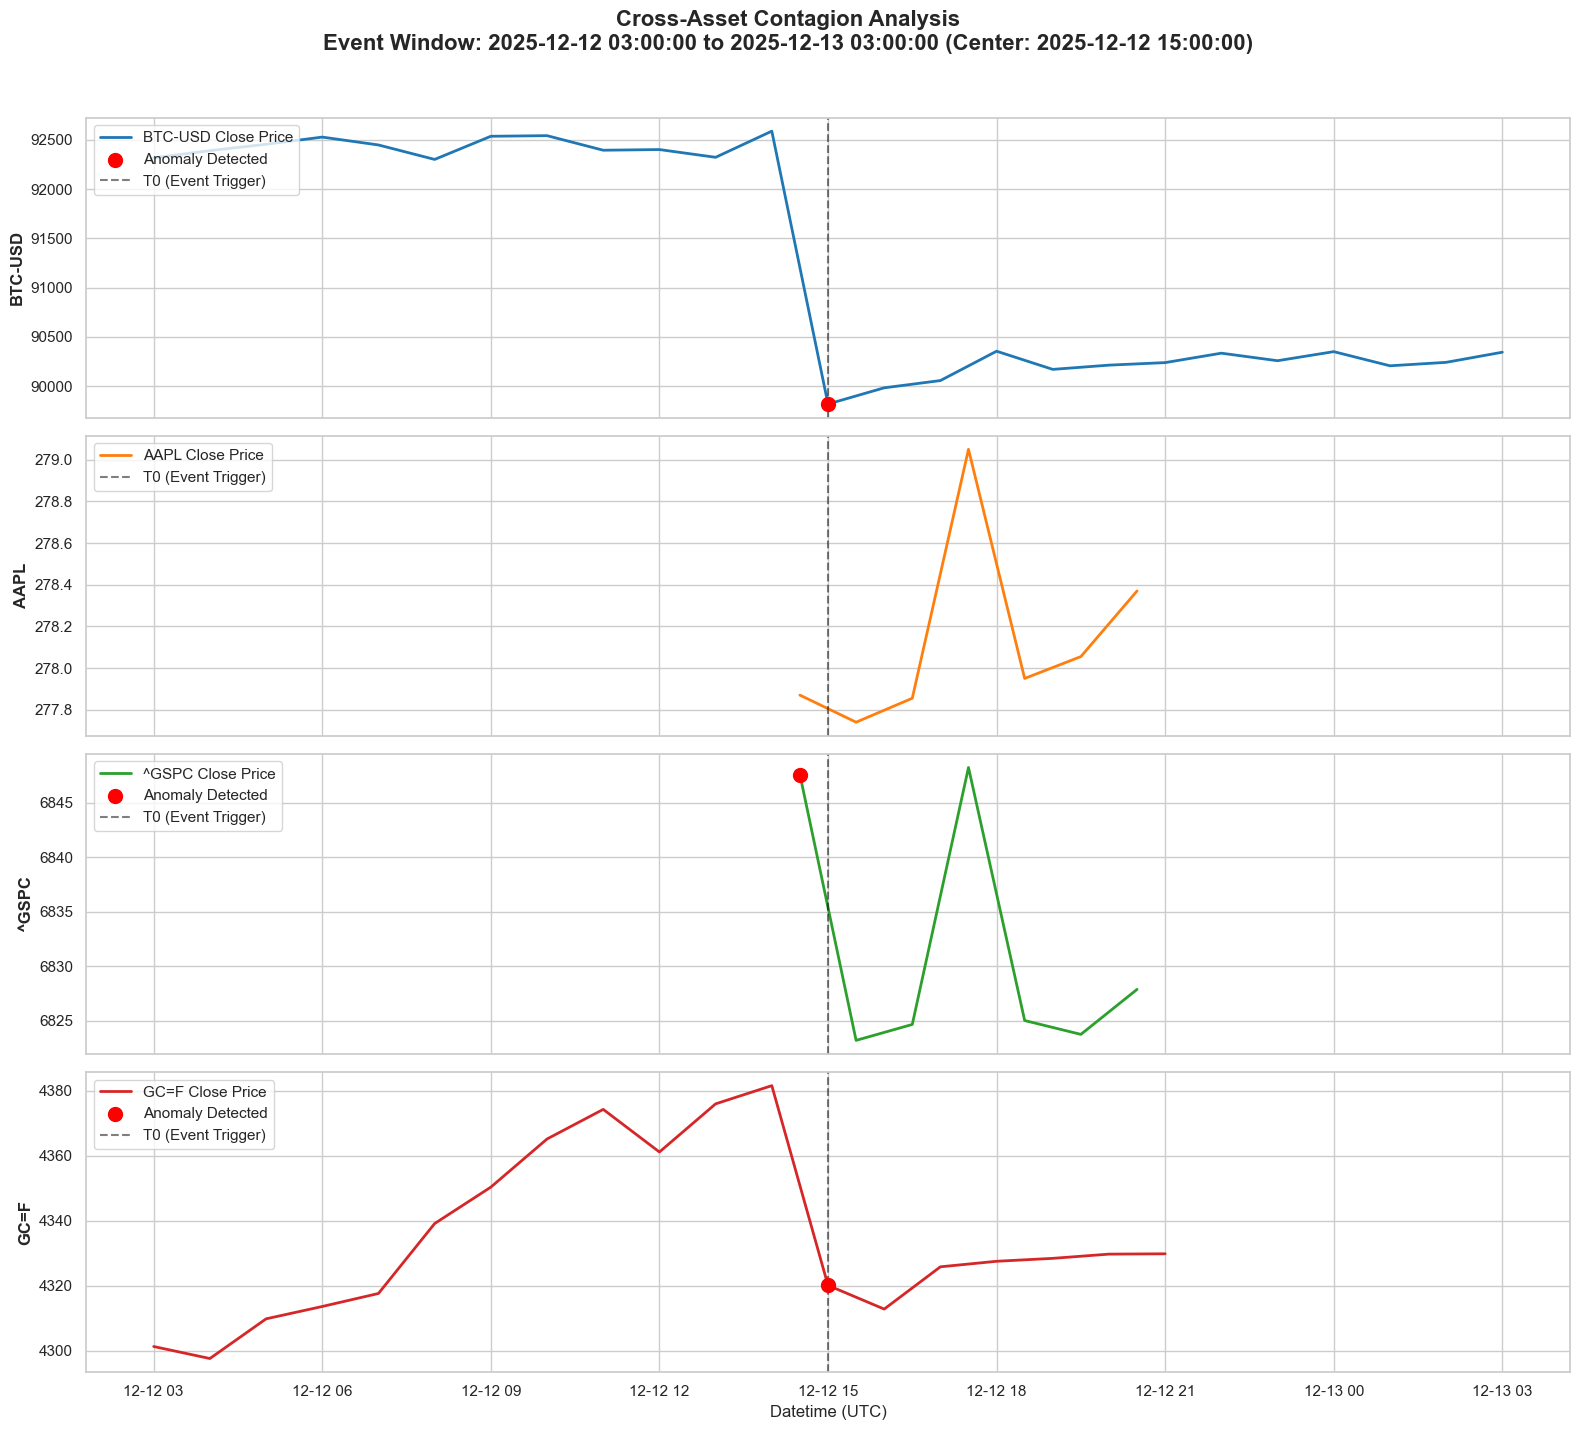

In [36]:
btc_crashes = real_crashes[real_crashes['symbol'] == 'BTC-USD']

if not btc_crashes.empty:
    target_event = btc_crashes.nsmallest(1, 'z_score_return').iloc[0]
    target_time = target_event['datetime']
    
    window_start = target_time - pd.Timedelta(hours=12)
    window_end = target_time + pd.Timedelta(hours=12)
    
    contagion_symbols = ['BTC-USD', 'AAPL', '^GSPC', 'GC=F']
    contagion_df = df[(df['symbol'].isin(contagion_symbols)) & 
                      (df['datetime'] >= window_start) & 
                      (df['datetime'] <= window_end)].copy()

    fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
    fig.suptitle(f"Cross-Asset Contagion Analysis\nEvent Window: {window_start} to {window_end} (Center: {target_time})", 
                 fontsize=16, fontweight='bold', y=1.02)
    
    for i, sym in enumerate(contagion_symbols):
        ax = axes[i]
        asset_data = contagion_df[contagion_df['symbol'] == sym]
        
        if not asset_data.empty:
            ax.plot(asset_data['datetime'], asset_data['close'], label=f'{sym} Close Price', color=sns.color_palette("tab10")[i], linewidth=2)
            
            asset_anomalies = asset_data[asset_data['anomaly_flag'] == True]
            if not asset_anomalies.empty:
                ax.scatter(asset_anomalies['datetime'], asset_anomalies['close'], color='red', s=100, zorder=5, label='Anomaly Detected')
            
            ax.axvline(x=target_time, color='black', linestyle='--', alpha=0.5, label='T0 (Event Trigger)')
            
            ax.set_ylabel(sym, fontweight='bold', fontsize=12)
            ax.legend(loc='upper left')
        else:
            ax.text(0.5, 0.5, f"No data for {sym} (Market Closed)", ha='center', va='center', transform=ax.transAxes)
            ax.set_ylabel(sym)
            
    plt.xlabel("Datetime (UTC)")
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy sự kiện Crash nào của BTC để làm Case Study.")

## **Phân tích lây lan rủi ro**

Quan sát quanh thời điểm **T0 = 15:00:00 UTC** *(10:00 New York – ngay sau khi mở cửa phiên Mỹ)* cho thấy một mẫu hình rất rõ của **lây lan rủi ro hệ thống**.
### **1. Xác nhận cú sốc vĩ mô**

Tại đúng thời điểm T0, cả **Bitcoin**, **S&P 500 Index** và **Gold Futures** đều đồng loạt xuất hiện điểm bất thường.

Điều này cho thấy:

* Không phải cú sốc riêng lẻ của Crypto
* Mà là một **tin vĩ mô tác động toàn thị trường**
* Thường liên quan đến dữ liệu kinh tế hoặc chính sách tiền tệ bất ngờ

### **2. Phản ứng thị trường và thanh khoản**

* **BTC & S&P 500:** phản ứng gần như tức thì bằng cú giảm mạnh tại T0

* Hành vi này phản ánh hoạt động của **HFT (High-Frequency Trading)** và dòng tiền bị “forced sell”

* Áp lực bán xuất hiện đồng thời trên nhiều lớp tài sản

* **Apple Inc.:**
  Có biến động mạnh theo dạng gap nhưng không bị đánh dấu anomaly
  → cho thấy hệ thống đã phân biệt được “biến động bình thường theo phiên mở cửa” và “cú sốc bất thường thực sự”


### **3. Nghịch lý của Vàng**

Điểm đáng chú ý nhất nằm ở **Gold Futures**:

* Trước T0: vàng tăng mạnh
* Tại T0: vàng giảm mạnh đồng thời với cổ phiếu và crypto

**Giải thích:**

* Khi thị trường rơi vào căng thẳng cực độ
* Nhà đầu tư buộc phải **bán cả tài sản an toàn để gọi ký quỹ (margin call)**
* Đây là hiện tượng **“thắt chặt thanh khoản” (liquidity crunch)** điển hình

### **Kết luận**

Trong các trạng thái khủng hoảng:

* Tương quan giữa các tài sản có xu hướng **tiến về 1**
* Rủi ro lan truyền thay vì phân tách theo nhóm tài sản
* Các giả định “vàng luôn tăng khi thị trường sập” có thể bị phá vỡ


## **5. Tổng kết và định hướng mô hình hóa**

Từ hệ thống phát hiện dị biệt và phân tích lây lan rủi ro, có thể rút ra một số quy luật nền tảng phục vụ trực tiếp cho việc thiết kế mô hình dự báo:
### **1. Về cấu trúc thị trường**

* **Cấu trúc rủi ro phi đối xứng:**
  **Bitcoin** và nhóm Crypto có mật độ anomaly cao vượt trội.
  Trong khi đó, chứng khoán thường rủi ro theo dạng **sự kiện (event-driven)**, tạo ra các cú sốc dạng gap thay vì biến động liên tục.

* **Biến động tụ tập (Volatility Clustering):**
  Rủi ro không phân tán ngẫu nhiên mà xuất hiện theo **cụm trạng thái (regimes)**: bình ổn → căng thẳng → hoảng loạn.

* **Hiệu ứng lây lan hệ thống (Contagion):**
  Khi xảy ra cú sốc vĩ mô, tương quan giữa các tài sản tăng mạnh, có thể tiến gần về 1.
  Ngay cả tài sản phòng thủ như **Gold Futures** cũng có thể bị bán tháo do áp lực thanh khoản.

### **2. Định hướng cho mô hình hóa**

* **Feature Engineering bắt buộc:**

  * `is_anomaly`
  * `rolling_volatility`
    → giúp mô hình nhận diện trạng thái thị trường thay vì chỉ học giá trị.

* **Chuẩn hóa dữ liệu (Robust Scaling):**

  * Phân phối có đuôi béo làm sai lệch mean/variance
  * Ưu tiên **RobustScaler (median + IQR)** thay vì MinMax/StandardScaler

* **Thiết kế mô hình theo regime:**

  * Không dùng 1 mô hình duy nhất cho toàn bộ dữ liệu
  * Cần tách:
    * **Normal regime** (ổn định)
    * **Crisis regime** (biến động mạnh)

### **Kết luận**

Hệ thống thị trường tài chính không vận hành tuyến tính mà chuyển đổi liên tục giữa các trạng thái rủi ro. Vì vậy, mô hình dự báo hiệu quả cần:

* Nhận diện được **trạng thái thị trường**
* Thích ứng với **cụm biến động**
* Và xử lý tốt các **cú sốc hệ thống**